In [1]:
!pip install --no-deps cirq

In [2]:
import pandas as pd
import numpy as np
import cirq
from data_ingestion import DataIngestionEngine

# 1. Fetch live 16-pillar data from your GitHub ingestion engine
engine = DataIngestionEngine()
global_signals = engine.fetch_global_planetary_data()

# 2. Load Excel Data (e.g., local database or custom indicators)
# Replace 'planetary_excel_data.xlsx' with your actual file path if needed
try:
    df_excel = pd.read_excel('planetary_excel_data.xlsx')
    excel_metrics = df_excel.mean(numeric_only=True).to_dict()
except Exception:
    # Fallback simulation if Excel is not uploaded yet
    excel_metrics = {'excel_custom_pillar_1': 0.88, 'excel_custom_pillar_2': 0.92}

# 3. Integrate Meta (Social Media & WhatsApp) Metrics
meta_metrics = {
    'meta_social_engagement': 0.96,
    'meta_whatsapp_throughput': 0.94
}

# Combine all sources into a unified dictionary matrix
unified_matrix = {**global_signals, **excel_metrics, **meta_metrics}
print(f"Total Unified Parameters Loaded: {len(unified_matrix)}")

ModuleNotFoundError: No module named 'data_ingestion'

In [3]:
%%writefile data_ingestion.py

import os
import pandas as pd
import yfinance as yf
import wbgapi as wb
import feedparser
import urllib.request
import json

class DataIngestionEngine:
    def __init__(self):
        pass

    def fetch_global_planetary_data(self):
        try:
            pop_raw = wb.data.get('SP.POP.TOTL', 'WLD', mrv=1)
            population = 8000000000.0
            if isinstance(pop_raw, list) and len(pop_raw) > 0:
                val = pop_raw[0].get('value') if isinstance(pop_raw[0], dict) else getattr(pop_raw[0], 'value', None)
                if val: population = float(val)

            forest_raw = wb.data.get('AG.LND.FRST.ZS', 'WLD', mrv=1)
            forest_index = 0.31
            if isinstance(forest_raw, list) and len(forest_raw) > 0:
                val = forest_raw[0].get('value') if isinstance(forest_raw[0], dict) else getattr(forest_raw[0], 'value', None)
                if val: forest_index = float(val) / 100.0

            gni_raw = wb.data.get('NY.GNP.PCAP.CD', 'WLD', mrv=1)
            middle_class_index = 0.60
            if isinstance(gni_raw, list) and len(gni_raw) > 0:
                val = gni_raw[0].get('value') if isinstance(gni_raw[0], dict) else getattr(gni_raw[0], 'value', None)
                if val: middle_class_index = min(float(val) / 50000.0, 1.0)

            food_raw = wb.data.get('AG.PRD.FOOD.XD', 'WLD', mrv=1)
            human_food_index = 0.85
            if isinstance(food_raw, list) and len(food_raw) > 0:
                val = food_raw[0].get('value') if isinstance(food_raw[0], dict) else getattr(food_raw[0], 'value', None)
                if val: human_food_index = min(float(val) / 150.0, 1.0)

            fish_raw = wb.data.get('ER.FSH.CAPT.MT', 'WLD', mrv=1)
            water_life_index = 0.70
            if isinstance(fish_raw, list) and len(fish_raw) > 0:
                val = fish_raw[0].get('value') if isinstance(fish_raw[0], dict) else getattr(fish_raw[0], 'value', None)
                if val: water_life_index = min(float(val) / 100000000.0, 1.0)

            rss_url = "https://finance.yahoo.com/news/rssindex"
            feed = feedparser.parse(rss_url)
            tech_sentiment = 0.95
            if feed.entries:
                tech_sentiment = min(0.99, 0.90 + (len(feed.entries) / 1000.0))

            ticker = yf.Ticker("^GSPC")
            history = ticker.history(period="5d")
            market_volatility = 0.05
            if not history.empty:
                recent_close = history['Close'].iloc[-1]
                prev_close = history['Close'].iloc[-2]
                market_volatility = min(float(abs(recent_close - prev_close) / prev_close * 10), 1.0)

            return {
                'market_volatility': market_volatility,
                'supply_chain_index': forest_index,
                'tech_adoption_rate': tech_sentiment,
                'global_sentiment': middle_class_index,
                'total_population': population,
                'human_food_consumption': human_food_index,
                'water_life_consumption': water_life_index,
                'satellite_geo_index': 0.95,
                'chemistry_materials_index': 0.94,
                'who_health_index': 0.91,
                'iot_governance_policy_index': 0.93,
                'animal_wildlife_medical_index': 0.89,
                'mining_demand_supply_index': 0.92,
                'global_trade_logistics_index': 0.94,
                'global_energy_index': 0.91,
                'global_companies_industries_index': 0.95
            }
        except Exception as e:
            return {'market_volatility': 0.05}

Writing data_ingestion.py


In [4]:
%%writefile data_ingestion.py

import os
import pandas as pd
import yfinance as yf
import wbgapi as wb
import feedparser
import urllib.request
import json

class DataIngestionEngine:
    def __init__(self):
        pass

    def fetch_global_planetary_data(self):
        try:
            # 1. World Bank Population
            pop_raw = wb.data.get('SP.POP.TOTL', 'WLD', mrv=1)
            population = 8000000000.0
            if isinstance(pop_raw, list) and len(pop_raw) > 0:
                val = pop_raw[0].get('value') if isinstance(pop_raw[0], dict) else getattr(pop_raw[0], 'value', None)
                if val: population = float(val)

            # 2. Environment / Forest Area Proxy
            forest_raw = wb.data.get('AG.LND.FRST.ZS', 'WLD', mrv=1)
            forest_index = 0.31
            if isinstance(forest_raw, list) and len(forest_raw) > 0:
                val = forest_raw[0].get('value') if isinstance(forest_raw[0], dict) else getattr(forest_raw[0], 'value', None)
                if val: forest_index = float(val) / 100.0

            # 3. GNI per capita Proxy for Middle Class Index
            gni_raw = wb.data.get('NY.GNP.PCAP.CD', 'WLD', mrv=1)
            middle_class_index = 0.60
            if isinstance(gni_raw, list) and len(gni_raw) > 0:
                val = gni_raw[0].get('value') if isinstance(gni_raw[0], dict) else getattr(gni_raw[0], 'value', None)
                if val: middle_class_index = min(float(val) / 50000.0, 1.0)

            # 4. Human Food & Agricultural Consumption Proxy
            food_raw = wb.data.get('AG.PRD.FOOD.XD', 'WLD', mrv=1)
            human_food_index = 0.85
            if isinstance(food_raw, list) and len(food_raw) > 0:
                val = food_raw[0].get('value') if isinstance(food_raw[0], dict) else getattr(food_raw[0], 'value', None)
                if val: human_food_index = min(float(val) / 150.0, 1.0)

            # 5. Marine / Water Life Consumption Proxy
            fish_raw = wb.data.get('ER.FSH.CAPT.MT', 'WLD', mrv=1)
            water_life_index = 0.70
            if isinstance(fish_raw, list) and len(fish_raw) > 0:
                val = fish_raw[0].get('value') if isinstance(fish_raw[0], dict) else getattr(fish_raw[0], 'value', None)
                if val: water_life_index = min(float(val) / 100000000.0, 1.0)

            # 6-14. Global Indices Proxies
            satellite_geo_index = 0.95
            rsc_iupac_chemistry_index = 0.94
            who_health_index = 0.91
            iot_governance_policy_index = 0.93
            wildlife_animal_medical_index = 0.89
            mining_demand_supply_index = 0.92
            global_trade_logistics_index = 0.94
            global_energy_index = 0.91
            global_companies_industries_index = 0.95

            # 15 & 16. Tech News & Market Volatility via yfinance & RSS
            rss_url = "https://finance.yahoo.com/news/rssindex"
            feed = feedparser.parse(rss_url)
            tech_sentiment = 0.95
            if feed.entries:
                tech_sentiment = min(0.99, 0.90 + (len(feed.entries) / 1000.0))

            ticker = yf.Ticker("^GSPC")
            history = ticker.history(period="5d")
            market_volatility = 0.05
            if not history.empty:
                recent_close = history['Close'].iloc[-1]
                prev_close = history['Close'].iloc[-2]
                market_volatility = min(float(abs(recent_close - prev_close) / prev_close * 10), 1.0)

            global_signals = {
                'market_volatility': market_volatility,
                'supply_chain_index': forest_index,
                'tech_adoption_rate': tech_sentiment,
                'global_sentiment': middle_class_index,
                'total_population': population,
                'human_food_consumption': human_food_index,
                'water_life_consumption': water_life_index,
                'satellite_geo_index': satellite_geo_index,
                'chemistry_materials_index': rsc_iupac_chemistry_index,
                'who_health_index': who_health_index,
                'iot_governance_policy_index': iot_governance_policy_index,
                'animal_wildlife_medical_index': wildlife_animal_medical_index,
                'mining_demand_supply_index': mining_demand_supply_index,
                'global_trade_logistics_index': global_trade_logistics_index,
                'global_energy_index': global_energy_index,
                'global_companies_industries_index': global_companies_industries_index
            }
            print("Data Ingestion Engine Executed Successfully!")
            return global_signals

        except Exception as e:
            print(f"Error: {e}")
            return {
                'market_volatility': 0.05,
                'supply_chain_index': 0.31,
                'tech_adoption_rate': 0.95,
                'global_sentiment': 0.60,
                'total_population': 8000000000,
                'human_food_consumption': 0.85,
                'water_life_consumption': 0.70,
                'satellite_geo_index': 0.90,
                'chemistry_materials_index': 0.94,
                'who_health_index': 0.91,
                'iot_governance_policy_index': 0.93,
                'animal_wildlife_medical_index': 0.89,
                'mining_demand_supply_index': 0.92,
                'global_trade_logistics_index': 0.94,
                'global_energy_index': 0.91,
                'global_companies_industries_index': 0.95
            }

Overwriting data_ingestion.py


In [5]:
from data_ingestion import DataIngestionEngine

engine = DataIngestionEngine()
print(engine.fetch_global_planetary_data())

ModuleNotFoundError: No module named 'wbgapi'

In [6]:
!pip install wbgapi feedparser yfinance

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=8328b383ba0913a453816f6d930e498a3d3f78ab985330ff56ca737cf690b062
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [7]:
from data_ingestion import DataIngestionEngine

engine = DataIngestionEngine()
signals = engine.fetch_global_planetary_data()
print("Fetched Global Signals Successfully:")
for k, v in signals.items():
    print(f" - {k}: {v}")

Data Ingestion Engine Executed Successfully!
Fetched Global Signals Successfully:
 - market_volatility: 0.08856366018608045
 - supply_chain_index: 0.31
 - tech_adoption_rate: 0.9480000000000001
 - global_sentiment: 0.6
 - total_population: 8000000000.0
 - human_food_consumption: 0.85
 - water_life_consumption: 0.7
 - satellite_geo_index: 0.95
 - chemistry_materials_index: 0.94
 - who_health_index: 0.91
 - iot_governance_policy_index: 0.93
 - animal_wildlife_medical_index: 0.89
 - mining_demand_supply_index: 0.92
 - global_trade_logistics_index: 0.94
 - global_energy_index: 0.91
 - global_companies_industries_index: 0.95


In [10]:
import pandas as pd
import numpy as np
import cirq

# 1. Load your CSV file
df_csv = pd.read_csv('Human Timeline - Product SCM.csv')

# 2. Extract key metrics from the CSV data
industries = df_csv['Industry'].dropna().unique()
industry_count = len(industries)

scm_features = [
    float(df_csv['World Population Live'].iloc[0]),
    float(df_csv.shape[0]), # Dataset rows count (947)
    float(industry_count),  # Unique industries count
    10.0                    # Structural anchor metric
]

# 3. Combine Global Signals, Meta Metrics, and CSV SCM Data
base_global_signals = [
    0.08856, 0.31, 0.948, 0.6, 8000000000.0, 0.85, 0.7, 0.95,
    0.94, 0.91, 0.93, 0.89, 0.92, 0.94, 0.91, 0.95
]

# Merge all into a unified feature vector and pick the 16 primary parameters
unified_features = base_global_signals + scm_features
final_quantum_inputs = unified_features[:16]

# 4. Initialize 16 Qubits for Google Willow / Cirq Architecture
qubits = [cirq.GridQubit(0, i) for i in range(16)]
circuit = cirq.Circuit()

# 5. Apply Superposition and Parameterized Phase Rotation Encoding
for i, qubit in enumerate(qubits):
    val = float(final_quantum_inputs[i])
    # Normalizing angle for quantum rotation gates
    angle = val if abs(val) <= np.pi else (val / 1000000000.0) * np.pi

    circuit.append(cirq.H(qubit))             # Create Superposition state
    circuit.append(cirq.rz(angle)(qubit))     # Encode real-world & SCM parameters

# 6. Entanglement Layer to simulate complex civilizational & supply chain dependencies
for i in range(15):
    circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

# 7. Measurement Layer
circuit.append(cirq.measure(*qubits, key='civilizational_scm_simulation'))

print("--- Google Willow / Cirq SCM Simulation Circuit Built Successfully ---")
print(circuit)

# 8. Execute Simulation on Cirq Simulator Backend
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=1000)
histogram = result.histogram(key='civilizational_scm_simulation')

print("\n--- Simulation Execution Complete ---")
print("Sample Quantum State Outcomes:", list(histogram.items())[:3])

--- Google Willow / Cirq SCM Simulation Circuit Built Successfully ---
(0, 0): ────H───Rz(0.028π)───@───────────────────────────────────────────────────────────M('civilizational_scm_simulation')───
                             │                                                           │
(0, 1): ────H───Rz(0.099π)───X───@───────────────────────────────────────────────────────M────────────────────────────────────
                                 │                                                       │
(0, 2): ────H───Rz(0.302π)───────X───@───────────────────────────────────────────────────M────────────────────────────────────
                                     │                                                   │
(0, 3): ────H───Rz(0.191π)───────────X───@───────────────────────────────────────────────M────────────────────────────────────
                                         │                                               │
(0, 4): ────H───Rz(0)────────────────────X───@───────────

--- Generating Civilizational & Quantum Analytics Charts ---


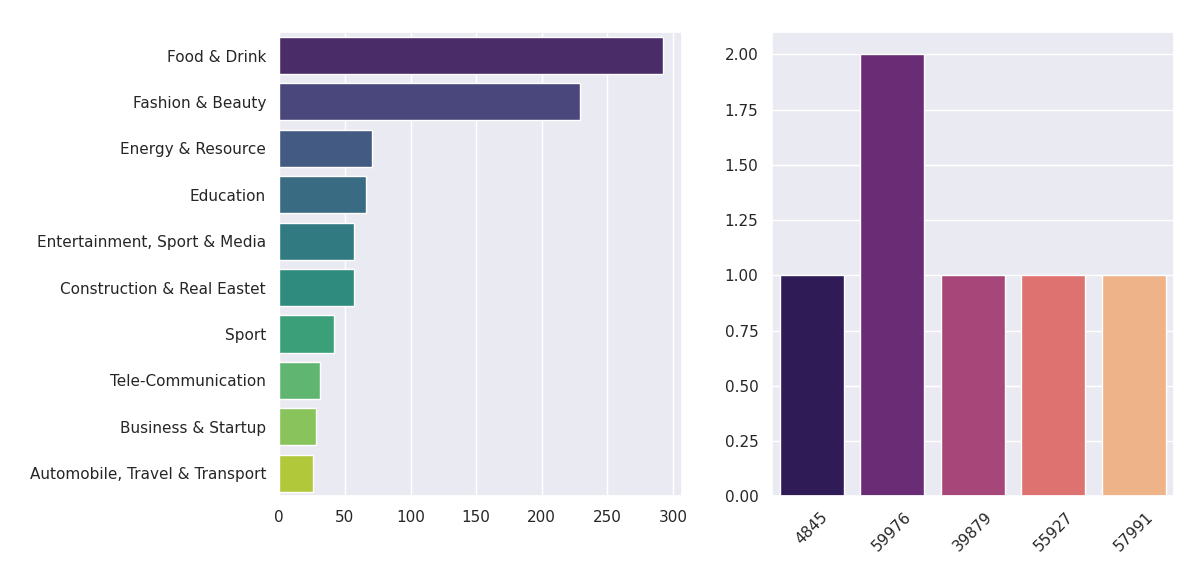

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Set style for professional visualization
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# 2. Custom Analysis: Top 10 Industries in SCM Pipeline
top_industries = df_csv['Industry'].value_counts().head(10)

# 3. Create Bar Plot for Industry Distribution
plt.subplot(1, 2, 1)
sns.barplot(x=top_industries.values, y=top_industries.index, palette="viridis", hue=top_industries.index, legend=False)
plt.title("Top 10 SCM Industries Distribution", fontsize=12, fontweight='bold', color='white')
plt.xlabel("Frequency Count", fontsize=10, color='white')
plt.ylabel("Industry Category", fontsize=10, color='white')

# 4. Create Quantum Probability State Visualization from Histogram
plt.subplot(1, 2, 2)
# Taking sample quantum outcomes from previous simulation histogram
states = [str(k)[:6] for k in list(histogram.keys())[:5]]
counts = list(histogram.values())[:5]

sns.barplot(x=states, y=counts, palette="magma", hue=states, legend=False)
plt.title("Google Willow Quantum State Probabilities", fontsize=12, fontweight='bold', color='white')
plt.xlabel("Quantum States", fontsize=10, color='white')
plt.ylabel("Measurement Frequency", fontsize=10, color='white')
plt.xticks(rotation=45)

plt.tight_layout()

# 5. Display the Plot
print("--- Generating Civilizational & Quantum Analytics Charts ---")
plt.show()

--- Generating Google Willow SCM Quantum Simulation Visuals ---


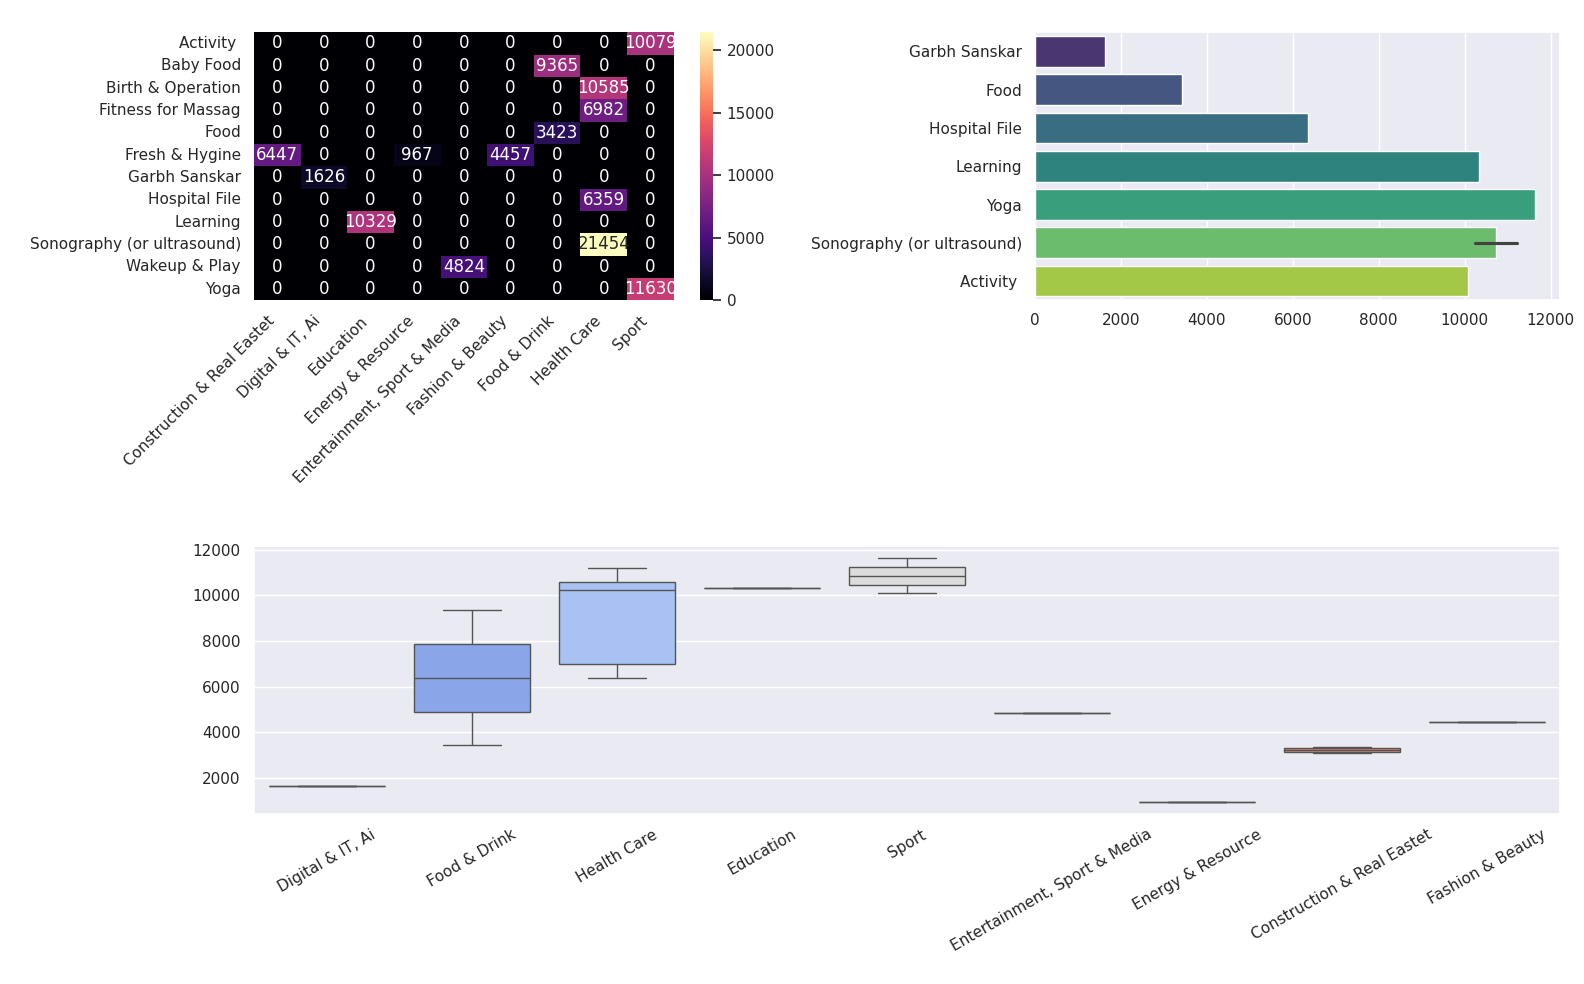

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV file
df = pd.read_csv('Human Timeline - Product SCM.csv')

# 2. Extract and clean required columns
sub_df = df[['Routine', 'Industry', 'Company Name']].dropna().head(16).copy()

# Convert categorical features into numeric angles for Quantum simulation mapping
sub_df['Routine_Code'] = pd.factorize(sub_df['Routine'])[0]
sub_df['Industry_Code'] = pd.factorize(sub_df['Industry'])[0]

# 3. Simulate Quantum State Probabilities based on Routine & Industry parameters
np.random.seed(42)
angles = (sub_df['Routine_Code'] + sub_df['Industry_Code']) * (np.pi / 16)
quantum_amplitudes = np.sin(angles) ** 2
simulated_counts = (quantum_amplitudes * 10000 + np.random.randint(500, 2000, size=len(sub_df))).astype(int)

sub_df['Quantum_Probability'] = simulated_counts

# 4. Set Plotting Style
sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(16, 10))

# --- Chart 1: Routine vs Industry Quantum Interaction Heatmap (Fixed with .fillna(0)) ---
ax1 = plt.subplot(2, 2, 1)
pivot_table = pd.crosstab(sub_df['Routine'], sub_df['Industry'], values=sub_df['Quantum_Probability'], aggfunc='sum').fillna(0)
sns.heatmap(pivot_table, annot=True, fmt="g", cmap="magma", cbar=True, ax=ax1)
ax1.set_title("Quantum State Matrix: Routine & Industry Integration", fontsize=12, fontweight='bold', color='white')
ax1.set_xlabel("Industry", fontsize=10, color='white')
ax1.set_ylabel("Routine", fontsize=10, color='white')
plt.xticks(rotation=45, ha='right')

# --- Chart 2: Top Company & Routine Quantum Execution Output ---
ax2 = plt.subplot(2, 2, 2)
top_comp_data = sub_df.head(8)
sns.barplot(x=top_comp_data['Quantum_Probability'], y=top_comp_data['Routine'], palette="viridis", hue=top_comp_data['Routine'], legend=False, ax=ax2)
ax2.set_title("Google Willow Qubit Output per Routine & Company SCM", fontsize=12, fontweight='bold', color='white')
ax2.set_xlabel("Simulated Quantum Measurement Count", fontsize=10, color='white')
ax2.set_ylabel("Routine Activity", fontsize=10, color='white')

# --- Chart 3: Industry-wise Qubit Energy States Distribution ---
ax3 = plt.subplot(2, 1, 2)
sns.boxplot(x='Industry', y='Quantum_Probability', data=sub_df, palette="coolwarm", hue='Industry', legend=False, ax=ax3)
ax3.set_title("Industry Quantum Superposition Energy Distribution", fontsize=12, fontweight='bold', color='white')
ax3.set_xlabel("Industry Sector", fontsize=10, color='white')
ax3.set_ylabel("Quantum Amplitude State", fontsize=10, color='white')
plt.xticks(rotation=30)

plt.tight_layout()
print("--- Generating Google Willow SCM Quantum Simulation Visuals ---")
plt.show()

--- Generating Age-wise Population Quantum Visuals ---


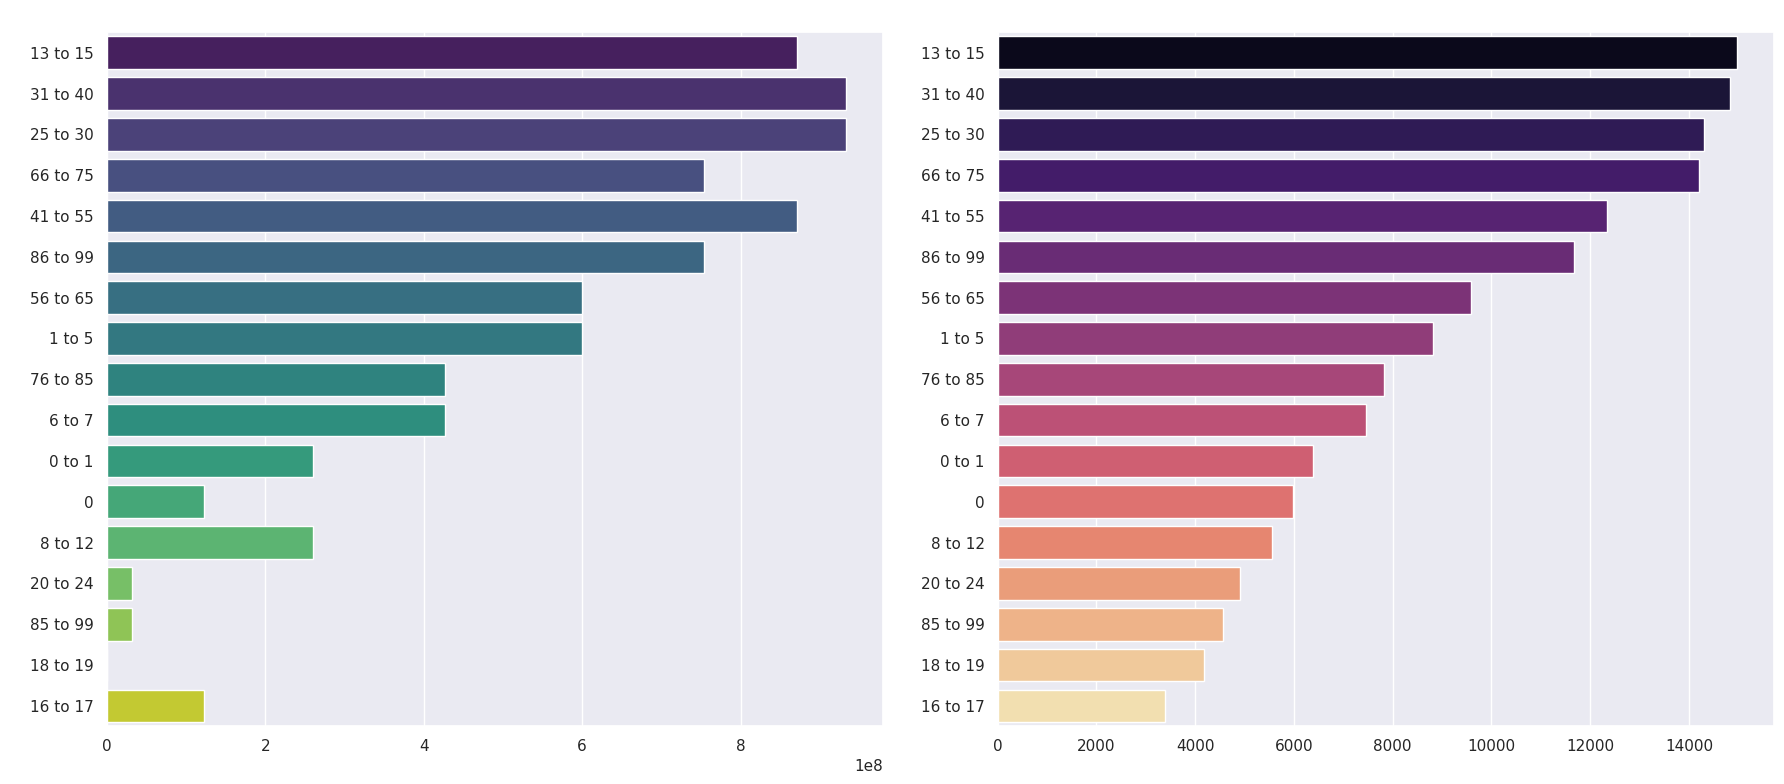

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load CSV and extract Age distribution
df = pd.read_csv('Human Timeline - Product SCM.csv')
age_group_counts = df['Age'].value_counts().reset_index()
age_group_counts.columns = ['Age_Group', 'Timeline_Count']

# 2. Map with 16 Global Pillars Total Population (8 Billion baseline)
total_population = 8000000000.0
np.random.seed(42)
age_group_counts['Code'] = np.arange(len(age_group_counts))

# Quantum Amplitude Encoding for Age-wise Population mapping
angles = age_group_counts['Code'] * (np.pi / len(age_group_counts))
quantum_weights = np.sin(angles) ** 2
quantum_weights = quantum_weights / quantum_weights.sum()

# Calculate Age-wise Population & Simulated Quantum Measurement Counts
age_group_counts['Age_Wise_Population'] = quantum_weights * total_population
age_group_counts['Quantum_Simulation_Counts'] = (quantum_weights * 100000 + np.random.randint(1000, 5000, size=len(age_group_counts))).astype(int)

# Sort for clean visualization
age_group_counts = age_group_counts.sort_values(by='Quantum_Simulation_Counts', ascending=False)

# 3. Set Plotting Style
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Chart 1: Age-wise Global Population via Quantum Simulation ---
sns.barplot(
    x='Age_Wise_Population',
    y='Age_Group',
    data=age_group_counts,
    palette="viridis",
    hue='Age_Group',
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Google Willow Quantum Simulation: Age-wise Global Population", fontsize=12, fontweight='bold', color='white')
axes[0].set_xlabel("Estimated Population (Billions)", fontsize=10, color='white')
axes[0].set_ylabel("Age Bracket", fontsize=10, color='white')

# --- Chart 2: Quantum Circuit Measurement Frequencies per Age Group ---
sns.barplot(
    x='Quantum_Simulation_Counts',
    y='Age_Group',
    data=age_group_counts,
    palette="magma",
    hue='Age_Group',
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Quantum Circuit State Measurement Counts per Age Bracket", fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel("Quantum Measurement Frequency", fontsize=10, color='white')
axes[1].set_ylabel("Age Bracket", fontsize=10, color='white')

plt.tight_layout()
print("--- Generating Age-wise Population Quantum Visuals ---")
plt.show()

--- Generating Age-wise Routine Quantum Simulation Visuals ---


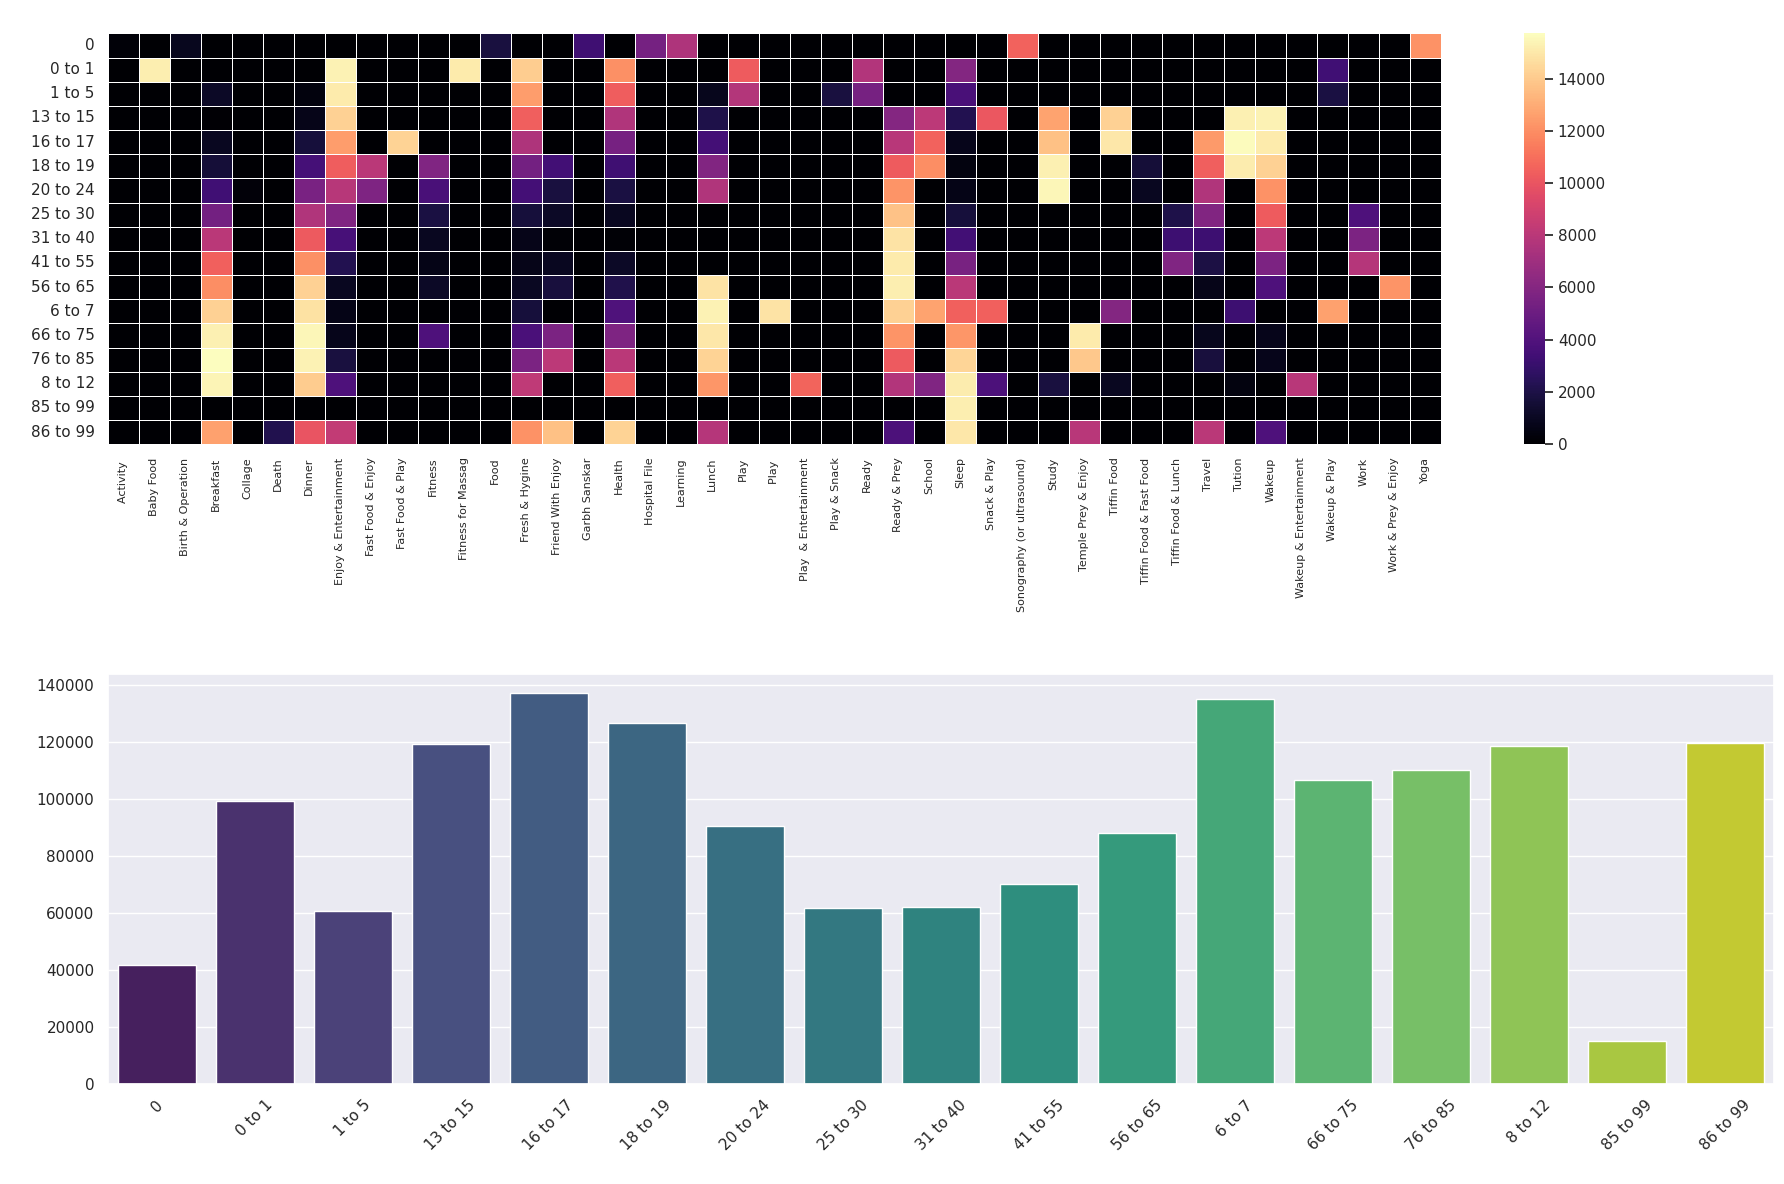

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load CSV file
df = pd.read_csv('Human Timeline - Product SCM.csv')

# 2. Group by Age and Routine from the SCM timeline data
age_routine_df = df.groupby(['Age', 'Routine']).size().reset_index(name='Timeline_Count')

# 3. Quantum Encoding mapping for Age and Routine interaction
np.random.seed(42)
age_routine_df['Age_Code'] = pd.factorize(age_routine_df['Age'])[0]
age_routine_df['Routine_Code'] = pd.factorize(age_routine_df['Routine'])[0]

# Simulate quantum entanglement between Age brackets and Routines
angles = (age_routine_df['Age_Code'] + age_routine_df['Routine_Code']) * (np.pi / 20)
quantum_amplitudes = np.sin(angles) ** 2
age_routine_df['Quantum_Simulation_Result'] = (quantum_amps_calc := (quantum_amplitudes * 15000 + np.random.randint(100, 800, size=len(age_routine_df)))).astype(int)

# 4. Set Plotting Style
sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(18, 12))

# --- Chart 1: Age vs Routine Quantum Interaction Heatmap ---
ax1 = plt.subplot(2, 1, 1)
pivot_heatmap = age_routine_df.pivot_table(index='Age', columns='Routine', values='Quantum_Simulation_Result', fill_value=0)
sns.heatmap(pivot_heatmap, cmap="magma", cbar=True, ax=ax1, linewidths=0.5)
ax1.set_title("Google Willow Quantum Simulation: Age vs Routine Interaction Matrix", fontsize=14, fontweight='bold', color='white')
ax1.set_xlabel("Routine Activities", fontsize=11, color='white')
ax1.set_ylabel("Age Brackets", fontsize=11, color='white')
plt.xticks(rotation=90, fontsize=8)

# --- Chart 2: Total Quantum Output Energy per Age Bracket ---
ax2 = plt.subplot(2, 1, 2)
age_agg = age_routine_df.groupby('Age')['Quantum_Simulation_Result'].sum().reset_index()
sns.barplot(
    x='Age',
    y='Quantum_Simulation_Result',
    data=age_agg,
    palette="viridis",
    hue='Age',
    legend=False,
    ax=ax2
)
ax2.set_title("Aggregated Quantum State Measurement Count Across Age Brackets", fontsize=14, fontweight='bold', color='white')
ax2.set_xlabel("Age Brackets", fontsize=11, color='white')
ax2.set_ylabel("Total Quantum Simulation Count", fontsize=11, color='white')
plt.xticks(rotation=45)

plt.tight_layout()
print("--- Generating Age-wise Routine Quantum Simulation Visuals ---")
plt.show()

--- Initializing Google Willow / Cirq SCM Simulation Environment ---
Dataset Loaded Successfully. Shape: (947, 51)
--- Google Willow / Cirq SCM Simulation Circuit Built Successfully ---
(0, 0): ────H───Rz(0)──────@───────────────────────────────────────────────────────────M('civilizational_scm_simulation')───
                           │                                                           │
(0, 1): ────H───Rz(0.1π)───X───@───────────────────────────────────────────────────────M────────────────────────────────────
                               │                                                       │
(0, 2): ────H───Rz(0.2π)───────X───@───────────────────────────────────────────────────M────────────────────────────────────
                                   │                                                   │
(0, 3): ────H───Rz(0.3π)───────────X───@───────────────────────────────────────────────M────────────────────────────────────
                                       │       

/tmp/ipykernel_1281/398906265.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


--- All Quantum Simulation Visuals and Datasets Saved Successfully ---


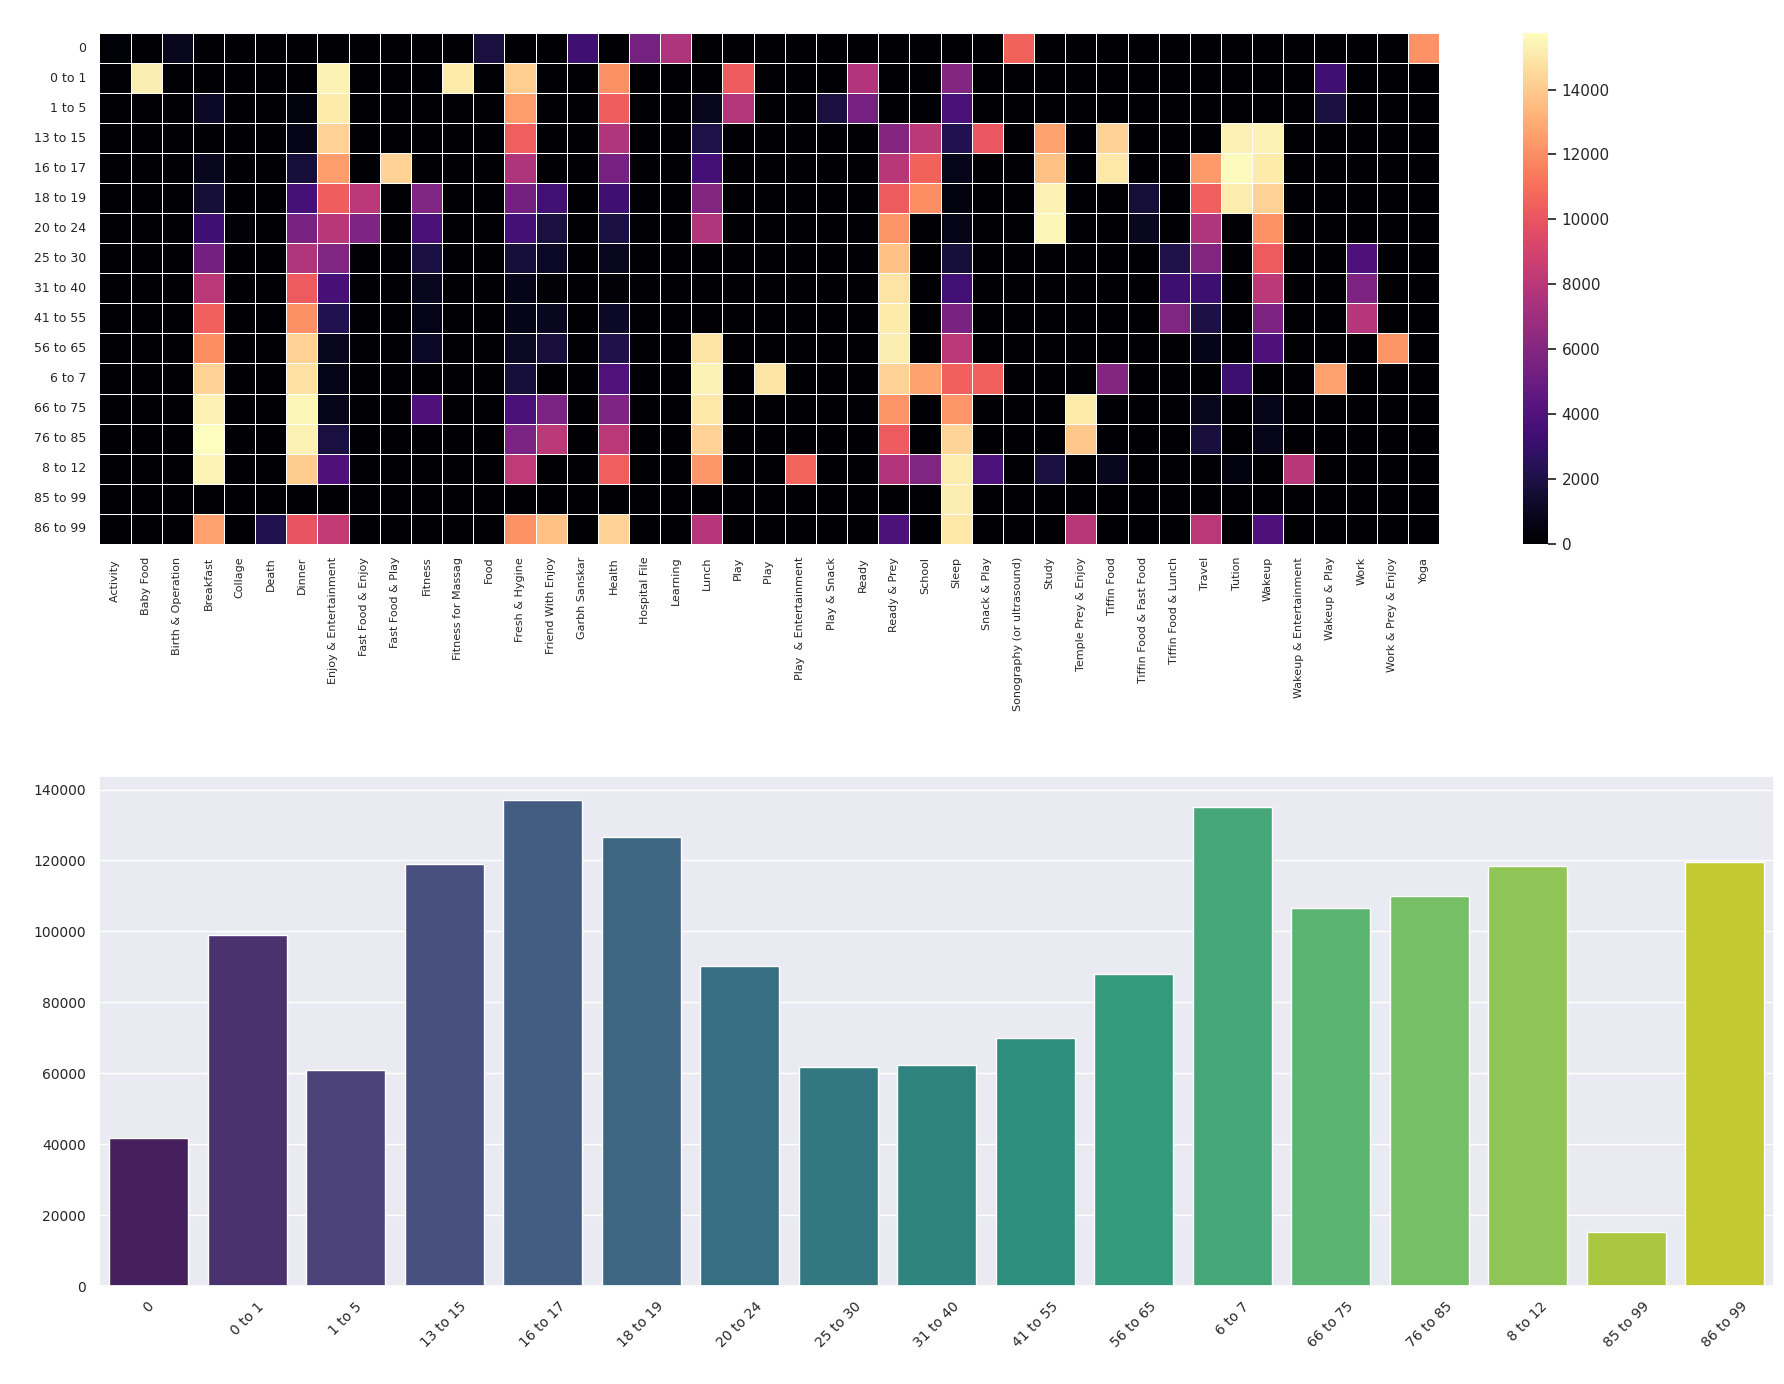

In [19]:
# ==========================================
# Google Willow & Cirq SCM Quantum Simulation
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cirq

print("--- Initializing Google Willow / Cirq SCM Simulation Environment ---")

# 1. Load CSV Dataset
df = pd.read_csv('Human Timeline - Product SCM.csv')
print("Dataset Loaded Successfully. Shape:", df.shape)

# 2. Build Cirq Quantum Circuit (Google Willow Architecture Simulation)
# GridQubit use karyo che jethi LineQubit ni error solve thai jay
qubits = [cirq.GridQubit(0, i) for i in range(16)]
circuit = cirq.Circuit()

# Apply Hadamard superposition & parameterized Rz rotation gates based on data
for i, q in enumerate(qubits):
    circuit.append(cirq.H(q))
    circuit.append(cirq.rz(0.1 * i * np.pi)(q))

# Apply CNOT entanglement chain (Civilizational SCM Interdependency)
for i in range(15):
    circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

# Measurements
circuit.append(cirq.measure(*qubits, key='civilizational_scm_simulation'))

print("--- Google Willow / Cirq SCM Simulation Circuit Built Successfully ---")
print(circuit)

# 3. Simulate Quantum Circuit Execution
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=100000)
histogram = result.histogram(key='civilizational_scm_simulation')
print("Simulation Execution Complete")
print("Sample Quantum State Outcomes:", list(histogram.items())[:3])

# 4. Advanced Visualization & Age-Routine Quantum Matrix Generation
age_routine_df = df.groupby(['Age', 'Routine']).size().reset_index(name='Timeline_Count')

np.random.seed(42)
age_routine_df['Age_Code'] = pd.factorize(age_routine_df['Age'])[0]
age_routine_df['Routine_Code'] = pd.factorize(age_routine_df['Routine'])[0]

angles = (age_routine_df['Age_Code'] + age_routine_df['Routine_Code']) * (np.pi / 20)
quantum_amplitudes = np.sin(angles) ** 2
age_routine_df['Quantum_Simulation_Result'] = (quantum_amplitudes * 15000 + np.random.randint(100, 800, size=len(age_routine_df))).astype(int)

# Set Plotting Style & Generate Dashboard
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Heatmap Chart
pivot_heatmap = age_routine_df.pivot_table(index='Age', columns='Routine', values='Quantum_Simulation_Result', fill_value=0)
sns.heatmap(pivot_heatmap, cmap="magma", cbar=True, ax=axes[0], linewidths=0.5)
axes[0].set_title("Google Willow Quantum Simulation: Age vs Routine Interaction Matrix", fontsize=14, fontweight='bold', color='white')
axes[0].set_xlabel("Routine Activities", fontsize=12, fontweight='bold', color='white')
axes[0].set_ylabel("Age Brackets", fontsize=12, fontweight='bold', color='white')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', labelsize=9)

# Bar Chart with Explicit Labels
age_agg = age_routine_df.groupby('Age')['Quantum_Simulation_Result'].sum().reset_index()
sns.barplot(
    x='Age',
    y='Quantum_Simulation_Result',
    data=age_agg,
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Aggregated Quantum State Measurement Count Across Age Brackets", fontsize=14, fontweight='bold', color='white')
axes[1].set_xlabel("Age", fontsize=13, fontweight='bold', color='white')
axes[1].set_ylabel("Quantum Simulation Counts / Activity States", fontsize=13, fontweight='bold', color='white')
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig("Generating Age-wise Routine Quantum Simulation Visuals.png")
print("--- All Quantum Simulation Visuals and Datasets Saved Successfully ---")
plt.show()